In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rapster.constants import *
from astropy.cosmology import Planck18

# Data loading

In [60]:
location = 'Results_Test/'

# load evolution:
evolution = pd.DataFrame(np.loadtxt(location+'evolution.txt'), columns=evolution_keys);

# load mergers:
mergers = pd.DataFrame(np.loadtxt(location+'mergers.txt'), columns=merger_keys);

# load hardening:
hardening = pd.DataFrame(np.loadtxt(location+'hardening.txt'), columns=hardening_keys);

# load tdes:
tdes = pd.DataFrame(np.loadtxt(location+'tdes.txt'), columns=tdes_keys);

# Cluster evolution

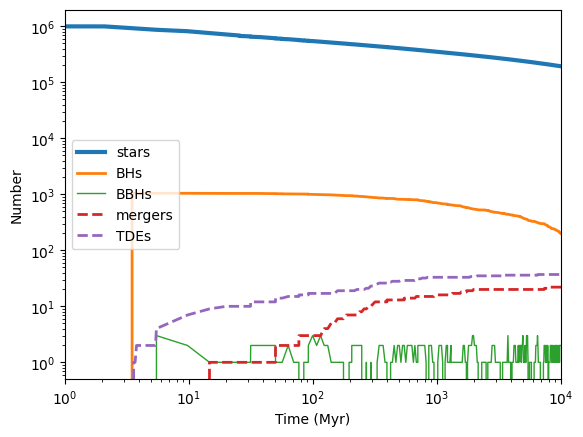

In [35]:
plt.plot(evolution['t'], evolution['M_cl']/evolution['m_avg'], lw=3, label=r'stars')
plt.plot(evolution['t'], evolution['N_BH'], lw=2, label=r'BHs')
plt.plot(evolution['t'], evolution['N_BBH'], lw=1, label=r'BBHs')
plt.plot(evolution['t'], evolution['N_me'], lw=2, ls='--', label=r'mergers')
plt.plot(evolution['t'], evolution['N_tdeBHWD']+evolution['N_tdeBHstar'], lw=2, ls='--', label=r'TDEs')

plt.legend()
plt.loglog()
plt.xlim(1, 1e4)
plt.xlabel(r'Time (Myr)')
plt.ylabel(r'Number')

plt.show()

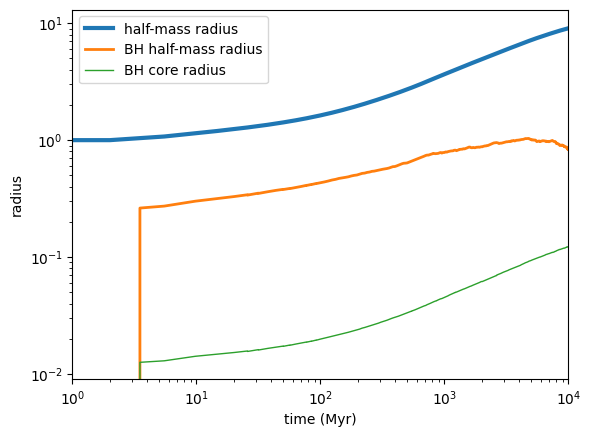

In [28]:
plt.plot(evolution['t'], evolution['r_h'], lw=3, label=r'half-mass radius')
plt.plot(evolution['t'], evolution['r_hBH'], lw=2, label=r'BH half-mass radius')
plt.plot(evolution['t'], evolution['r_cBH'], lw=1, label=r'BH core radius')

plt.legend()
plt.loglog()
plt.xlim(1, 1e4)
plt.xlabel(r'Time (Myr)')
plt.ylabel(r'Radius')

plt.show()

# BBH mergers

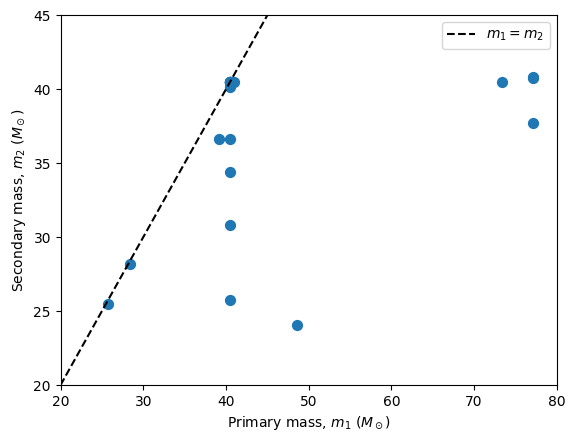

In [66]:
plt.scatter(mergers['m1'], mergers['m2'], s=50, marker='o')

x=np.linspace(0, 50)
plt.plot(x, x, color='k', ls='--', label=r'$m_1=m_2$')
plt.legend()
plt.xlim(20, 80)
plt.ylim(20, 45)
plt.xlabel(r'Primary mass, $m_1$ ($M_\odot$)')
plt.ylabel(r'Secondary mass, $m_2$ ($M_\odot$)')
plt.show()

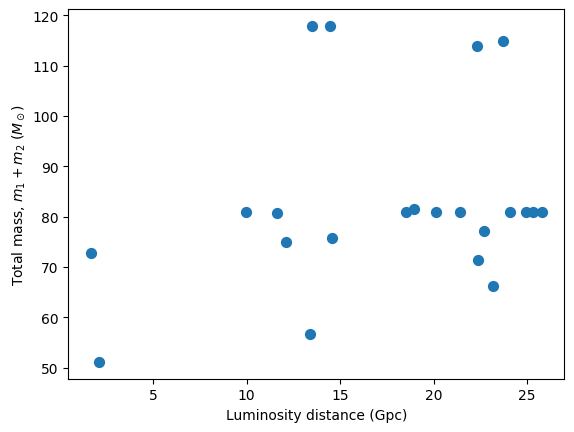

In [74]:
plt.scatter(Planck18.luminosity_distance(mergers['z'])/1e3, mergers['m1']+mergers['m2'], s=50, marker='o')

plt.xlabel(r'Luminosity distance (Gpc)')
plt.ylabel(r'Total mass, $m_1+m_2$ ($M_\odot$)')
plt.show()

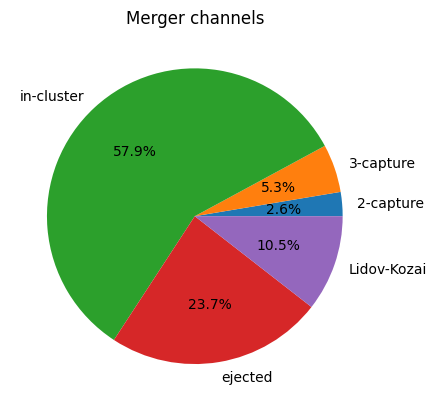

In [86]:
cap2 = (mergers['channel']==2)
cap3 = (mergers['channel']==6)
eject = mergers['channel']<0
zlk = mergers['channel']==4

sizes = [
    mergers['channel'][cap2].size, 
    mergers['channel'][cap3].size, 
    mergers['channel'][~(cap2*cap3*eject*zlk)].size, 
    mergers['channel'][eject].size, 
    mergers['channel'][zlk].size
]
labels = ['2-capture', '3-capture', 'in-cluster', 'ejected', 'Lidov-Kozai']

plt.title('Merger channels')
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.show()

# Tidal disruption events:

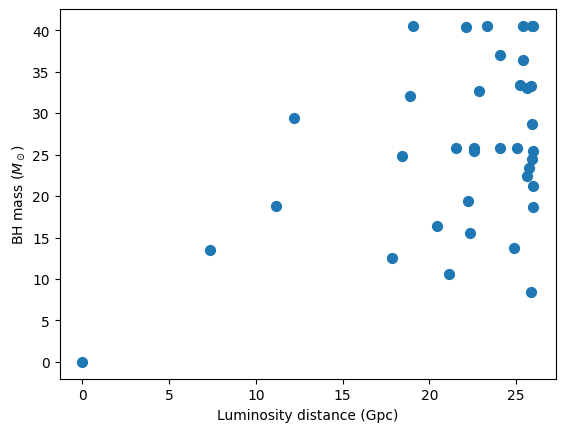

In [92]:
plt.scatter(Planck18.luminosity_distance(tdes['z'])/1e3, tdes['m_BH'], s=50, marker='o')

plt.xlabel(r'Luminosity distance (Gpc)')
plt.ylabel(r'BH mass ($M_\odot$)')
plt.show()